Note: Most of the code snippets and notes are based on "Intermediate Deep learning with Pytorch" course on DataCamp. Also some contents are AI generated.

# Part 1: Training Robust Neural Networks

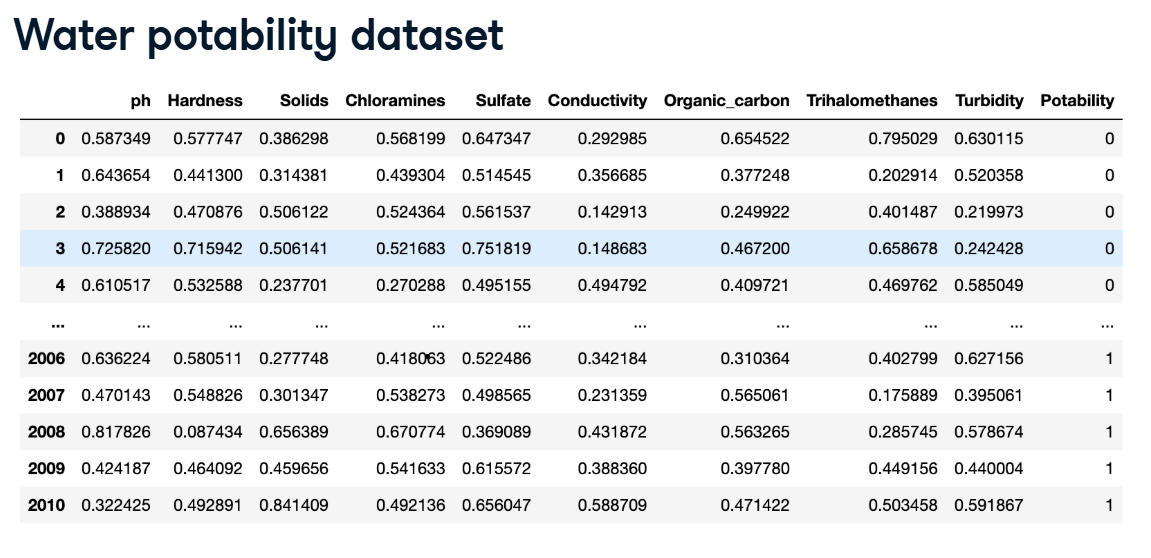

To train a model, we need to build a PyTorch Dataset, set up a DataLoader, and define the model.

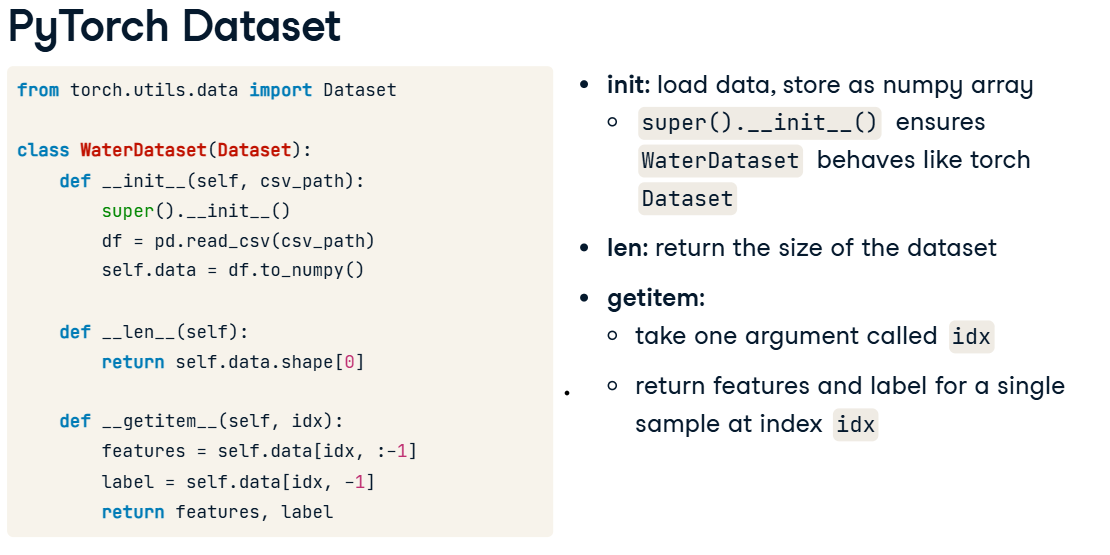

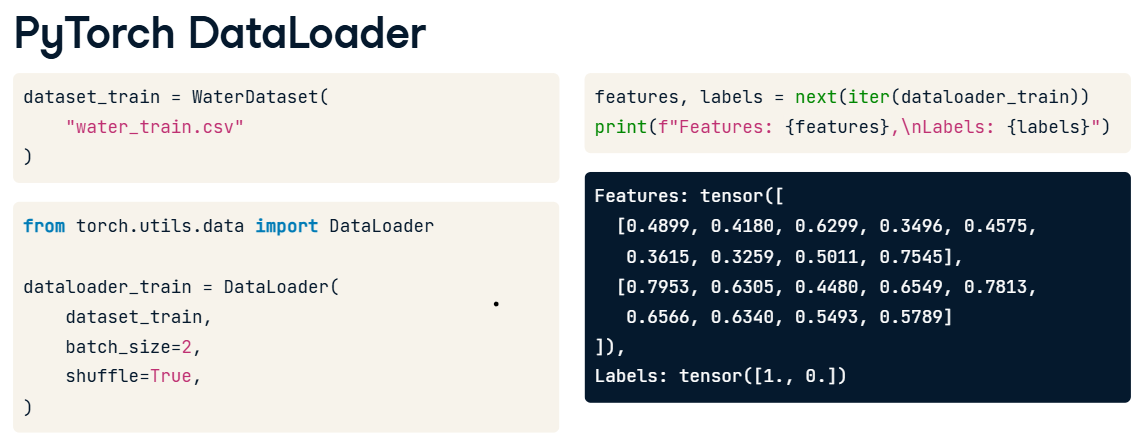

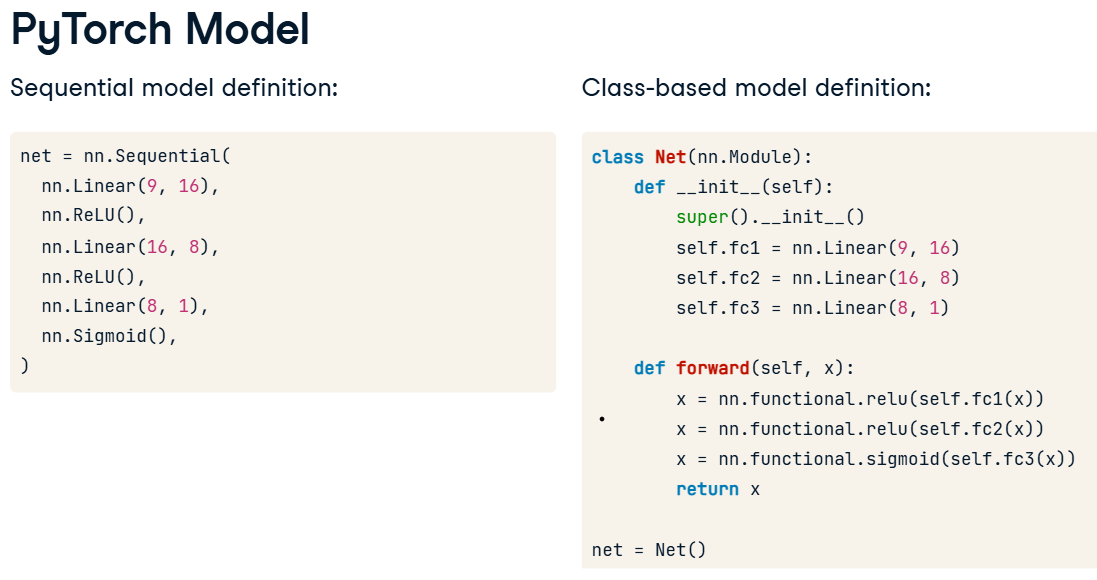


## Optimizers, training and evaluation

Let's review the PyTorch training loop. First, we define the loss function, conventionally called criterion, and the optimizer. We'll use Binary Cross-Entropy, or BCE Loss, commonly used for binary classification tasks. We use Stochastic Gradient Descent, or SGD, as the optimizer and tell it which parameters to optimize - here, it's all of net's parameters. Then we pass it the learning rate of point-zero-one. We start the loop by iterating over epochs and batches of training data. Next, we clear the gradients to start from zero for the new batch followed by a forward pass to get the model's outputs. Then, we compare the model's outputs to the ground-truth labels to compute the loss. We reshape the labels with the view method to match the shape of the outputs. We compute the gradients of the model's parameters for the loss using the backward method. These gradients contain information about the direction and size of the changes required to minimize the loss. Finally, we pass the gradients to the optimizer, which performs an optimization step. That is, it updates the values of the model's parameters based on the gradients.

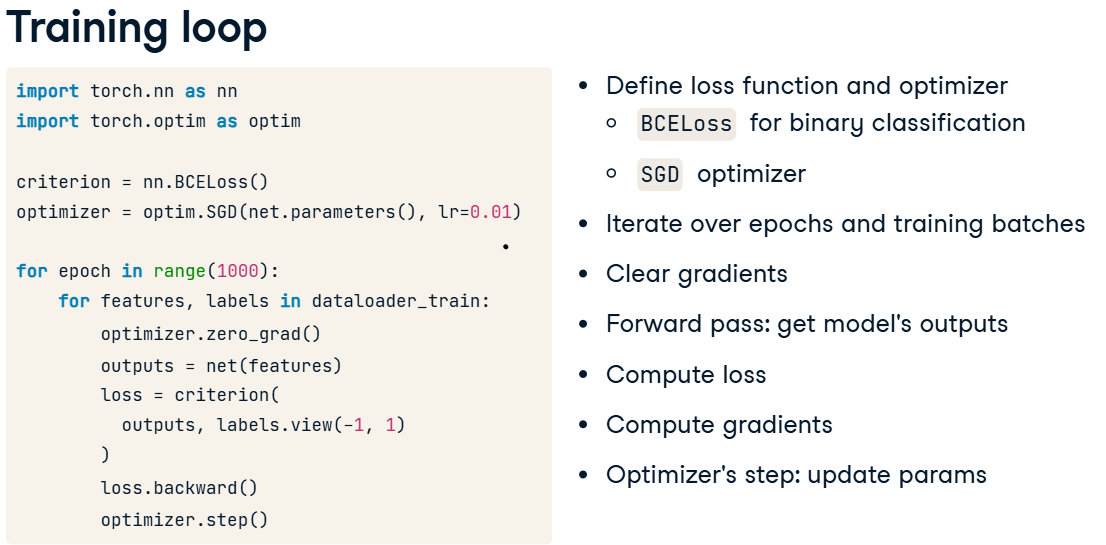

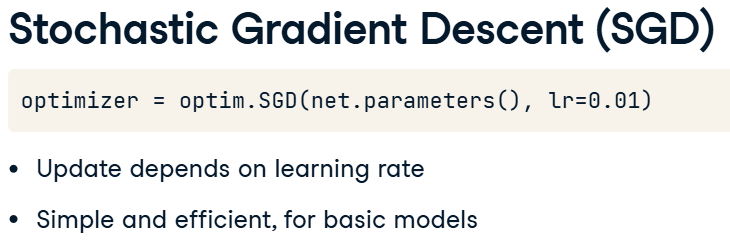

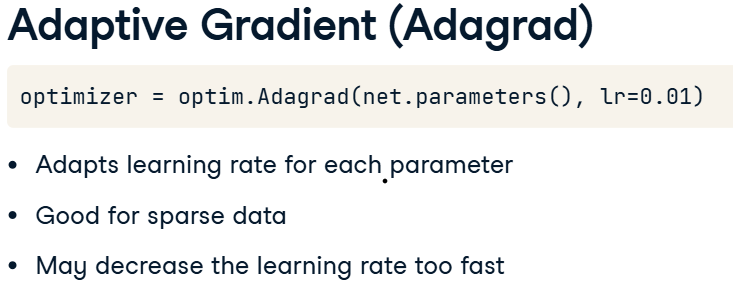

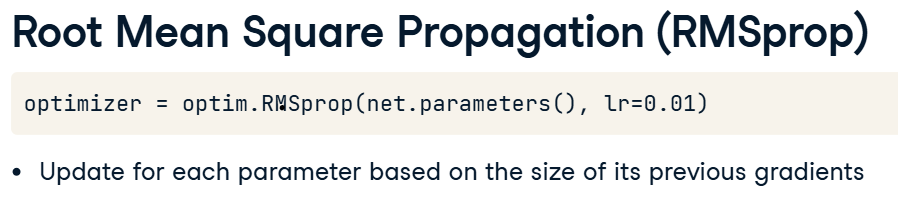

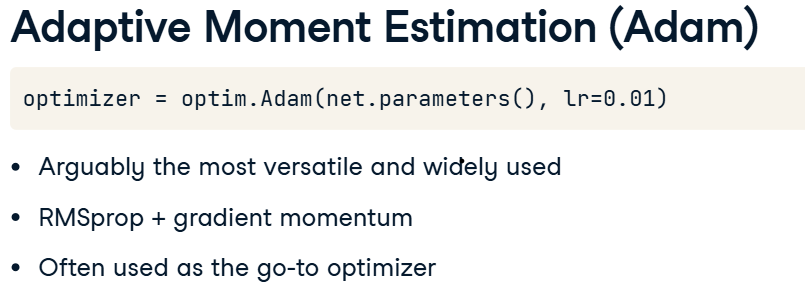

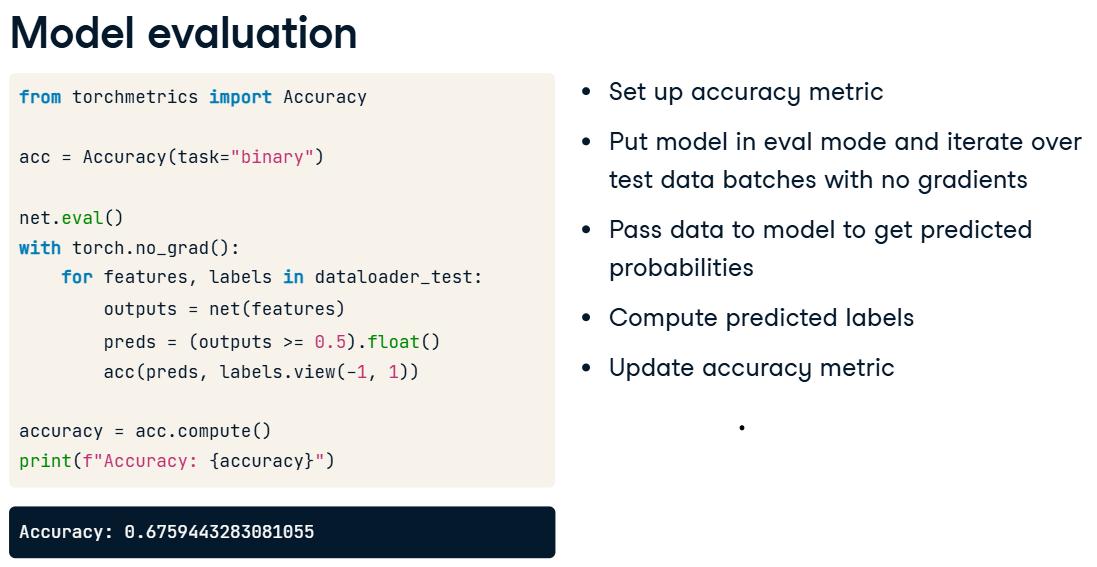

## Vanishing and Exploding gradients

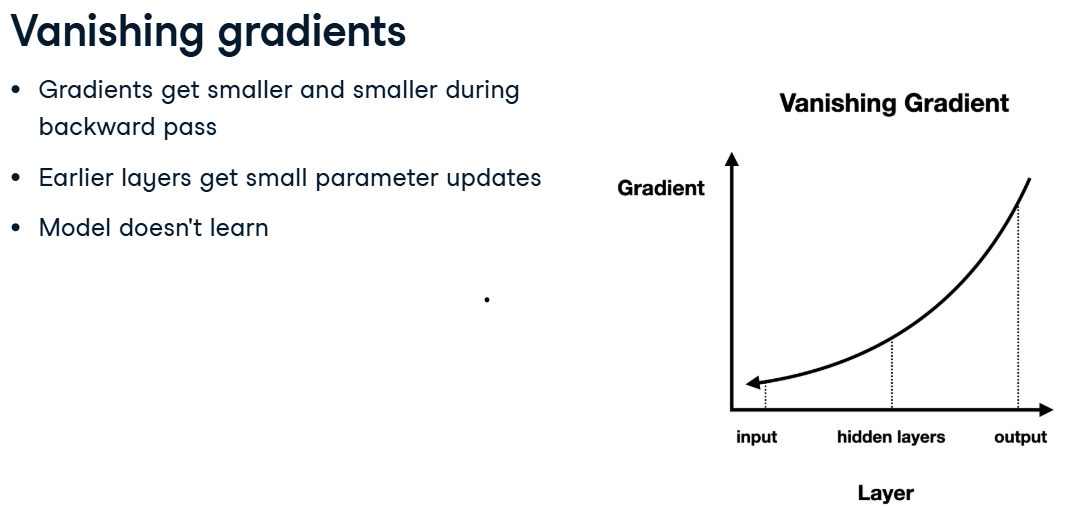
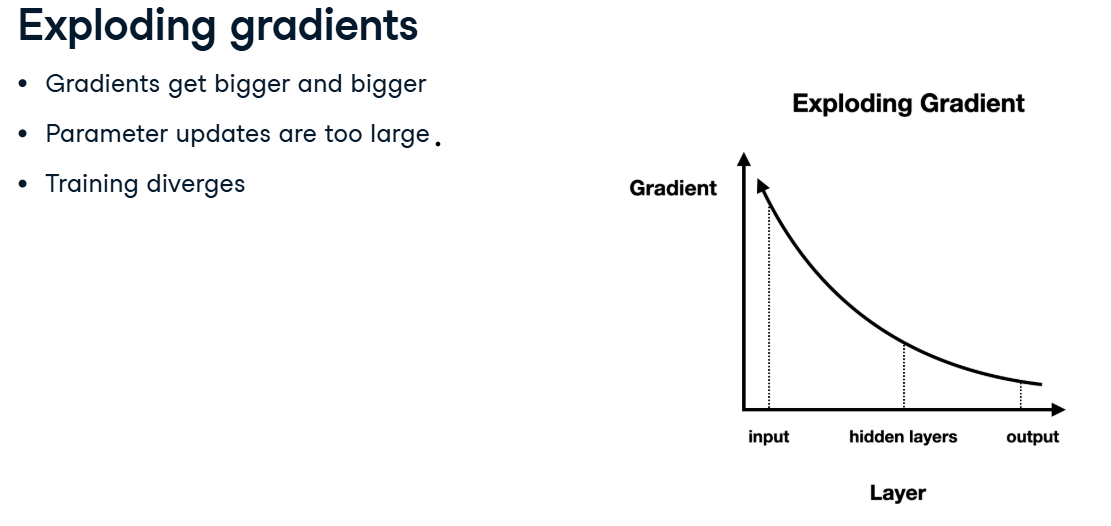

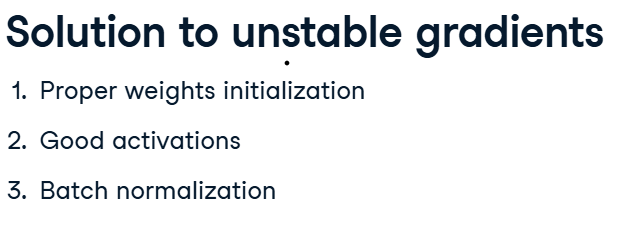

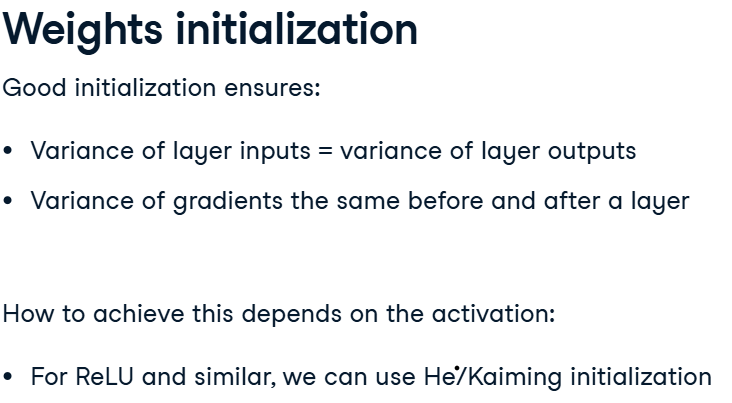

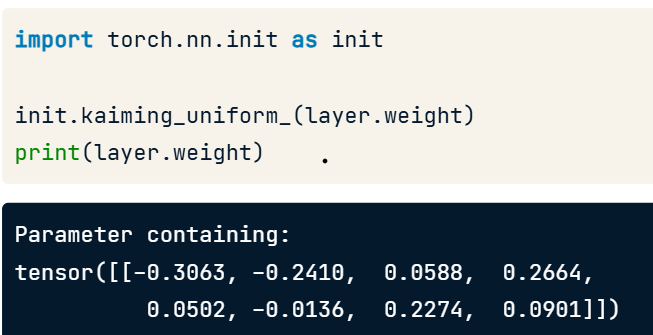

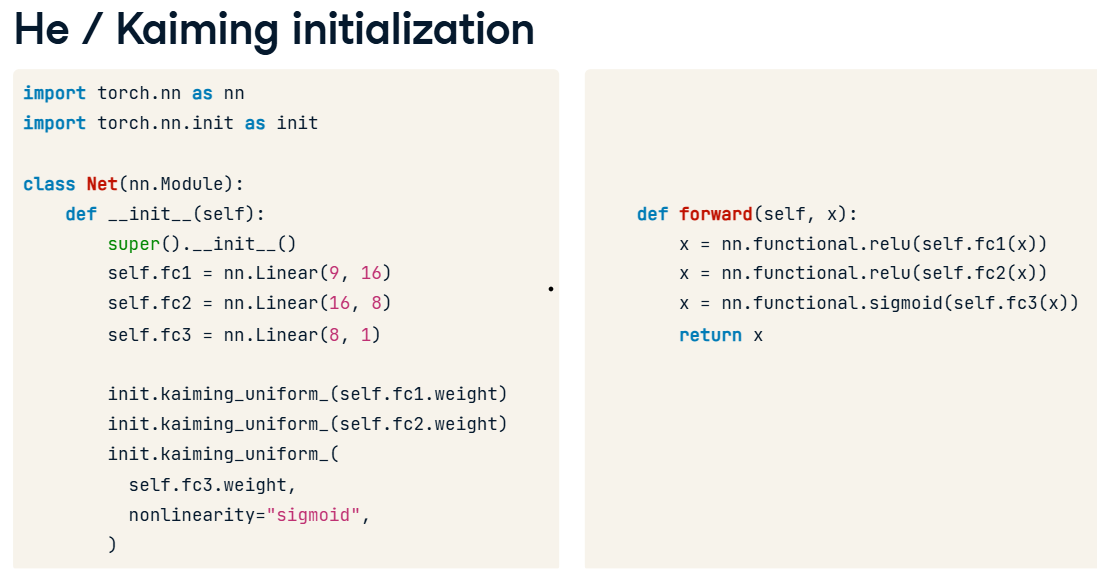

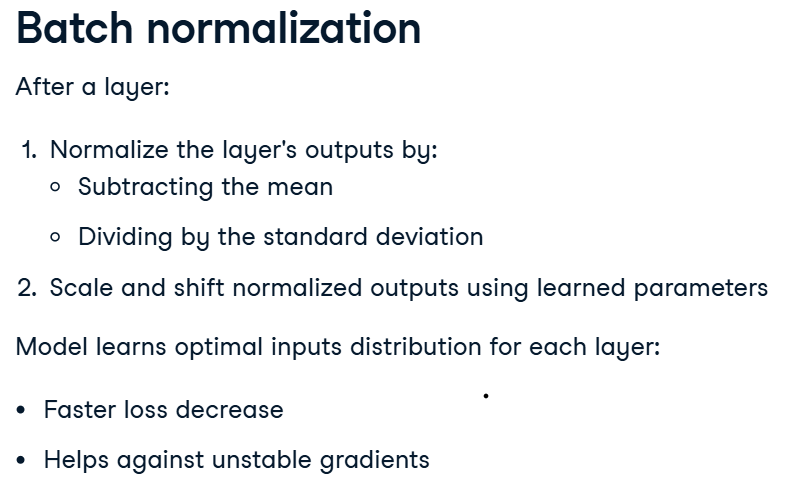

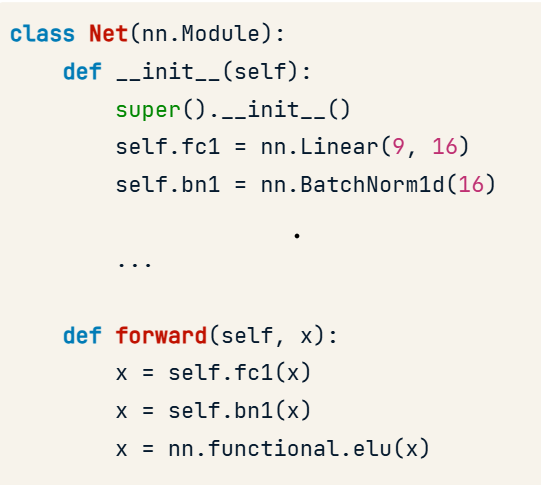

# Part 2: Images and CNN

## Handling images with Pytorch
We will work with the clouds dataset from Kaggle containing photos of seven different cloud types. We'll build an image classifier to predict the cloud from an image.

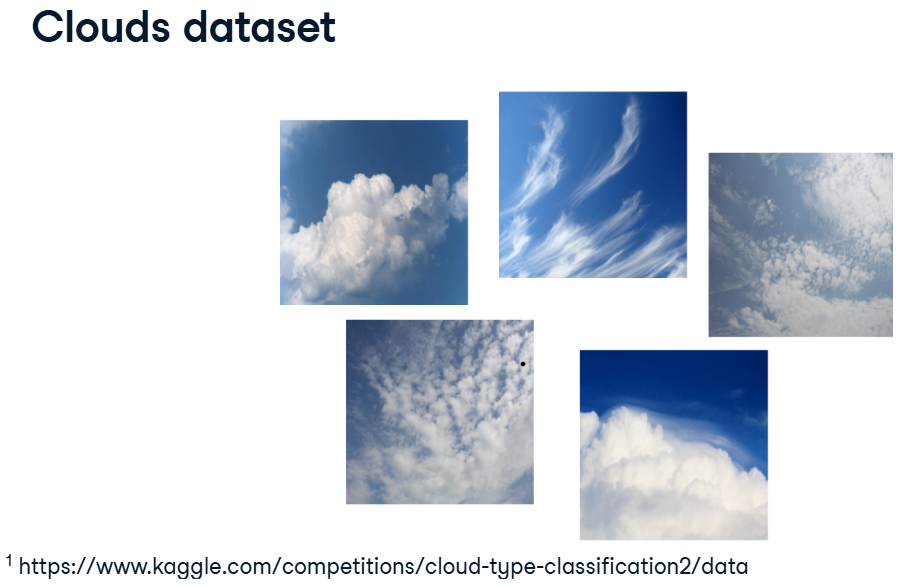

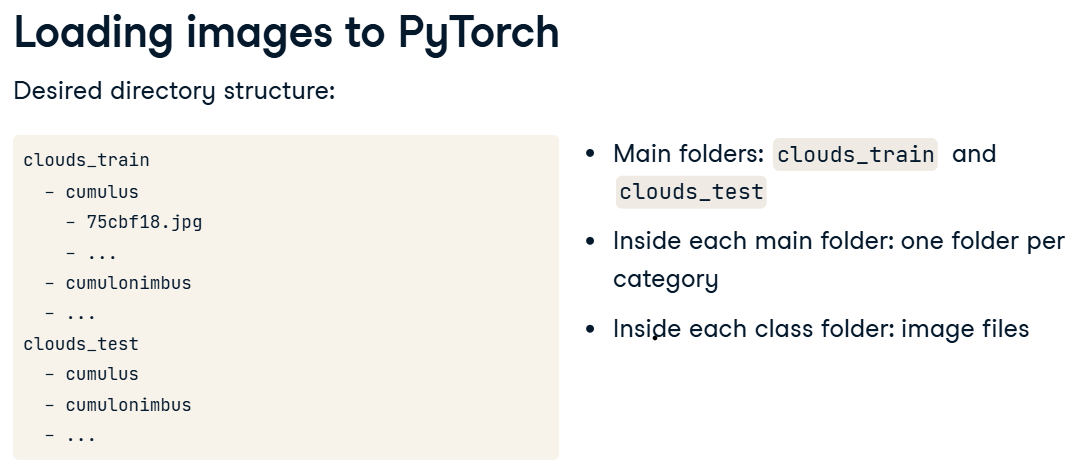

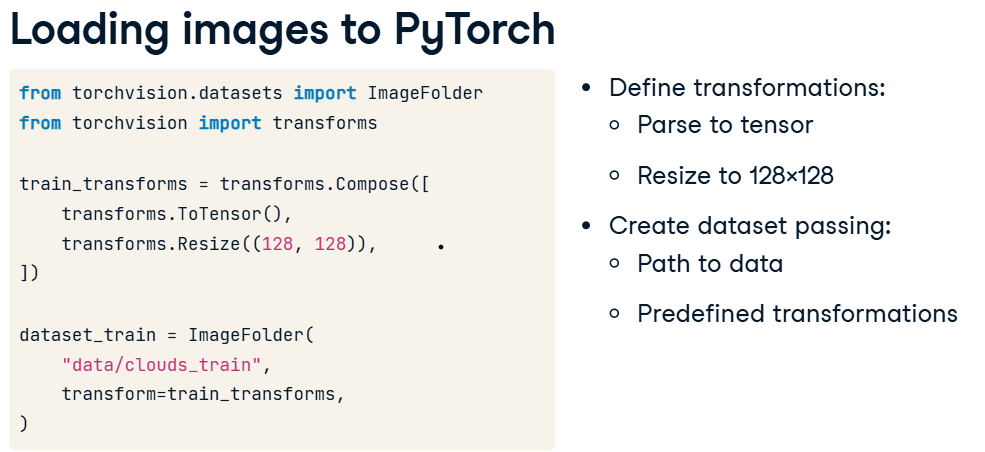

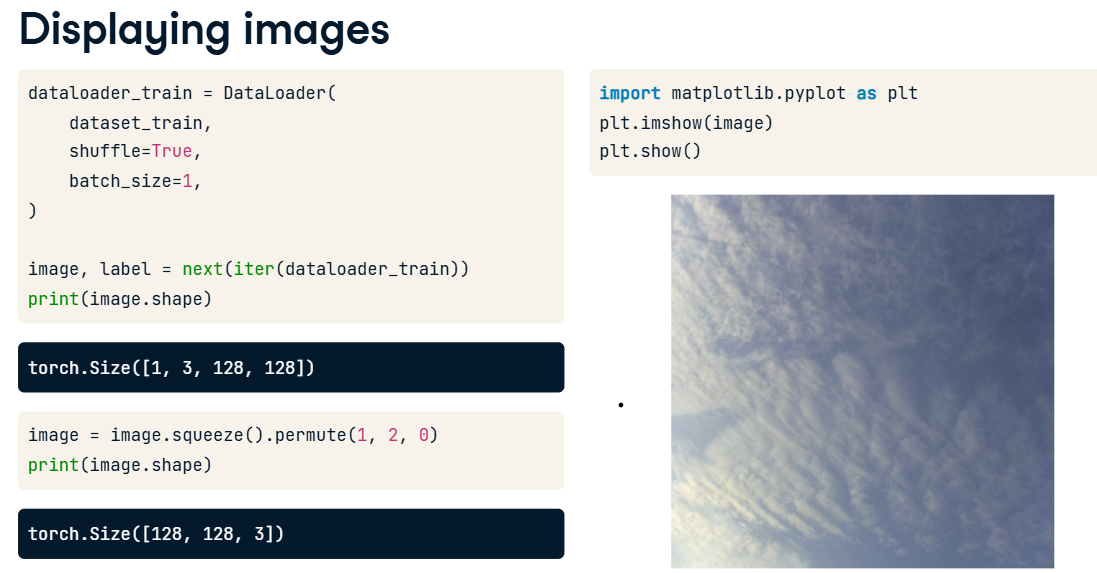

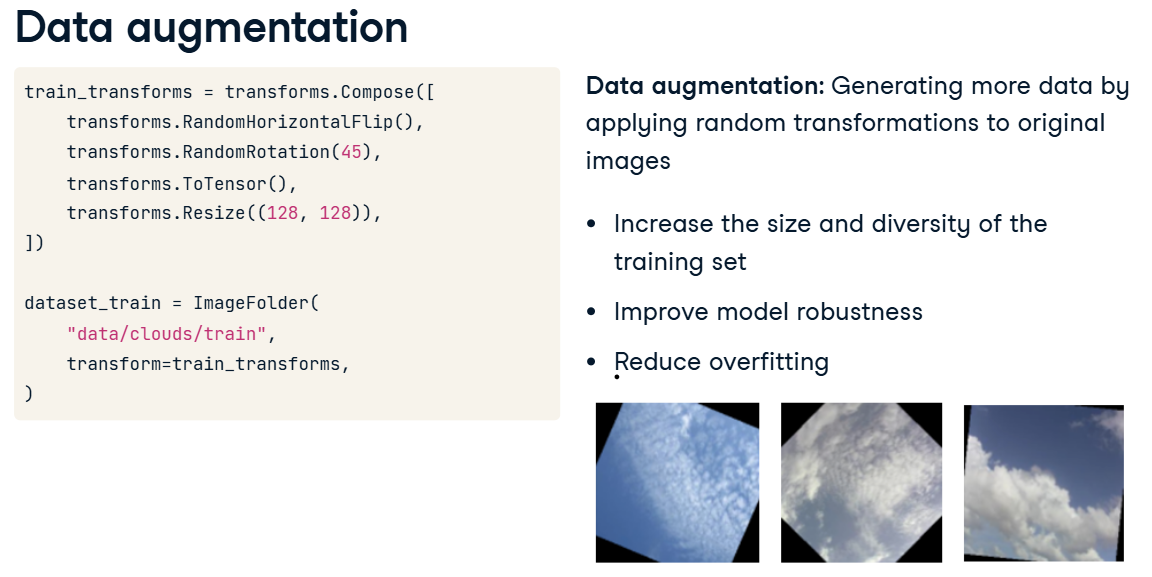


### CNN (Convolutional Neural Network):
A Convolutional Neural Network (CNN) is a type of deep learning model specifically designed to process data with a grid-like topology, such as images. CNNs are highly effective for tasks like image classification, object detection, face recognition, and even video analysis.

### Key Components of a CNN:
Convolutional Layers:
Apply filters to input data to extract features like edges, textures, and shapes.

Activation Functions (e.g., ReLU):
Introduce non-linearity to help the network learn complex patterns.

Pooling Layers (e.g., Max Pooling):
Reduce the spatial size of the feature maps, lowering computation and helping with overfitting.

Fully Connected Layers:
After feature extraction, these layers classify the image based on the learned features.


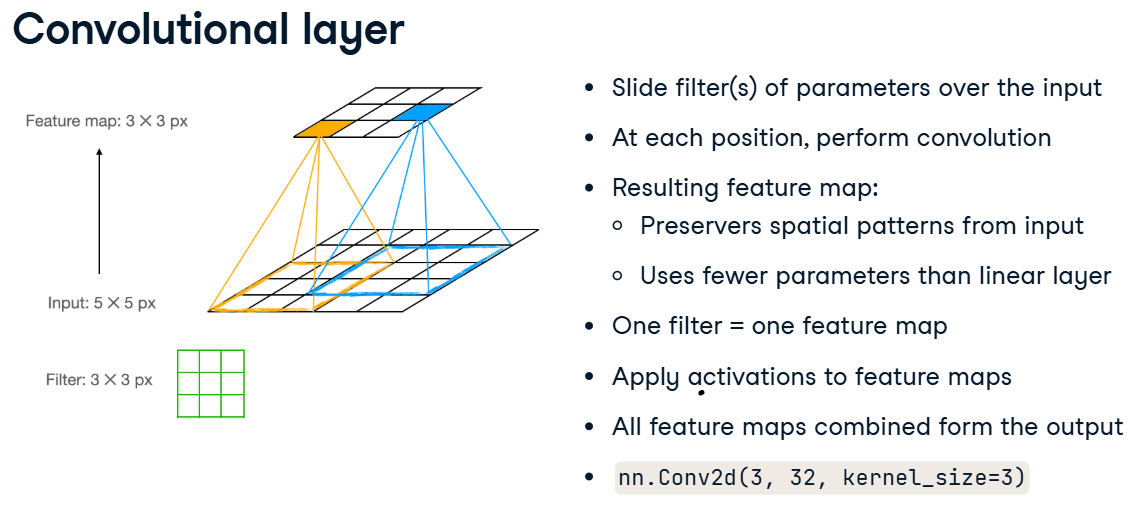

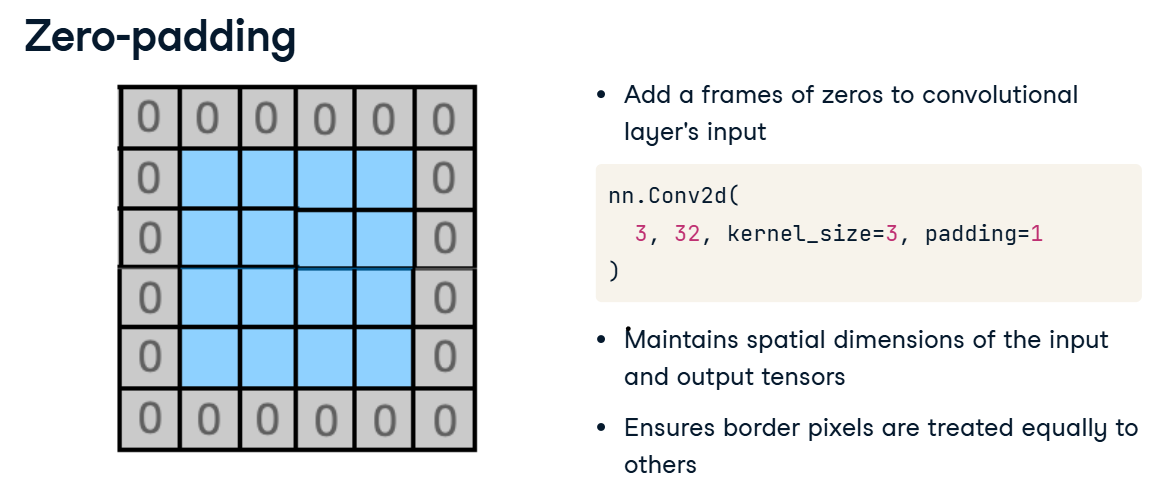

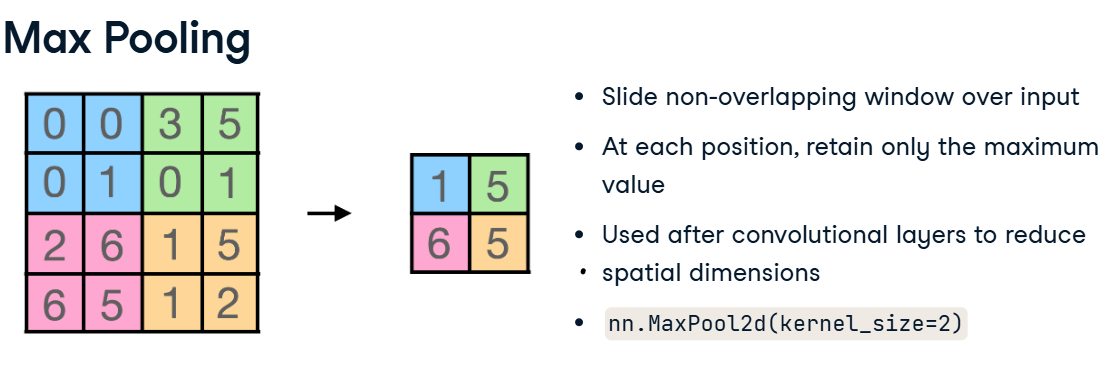

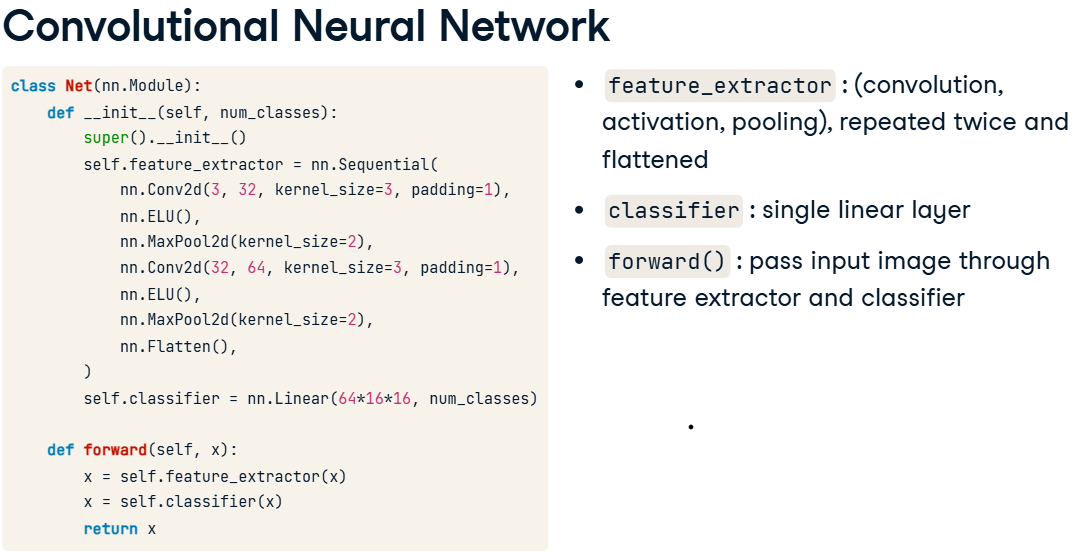

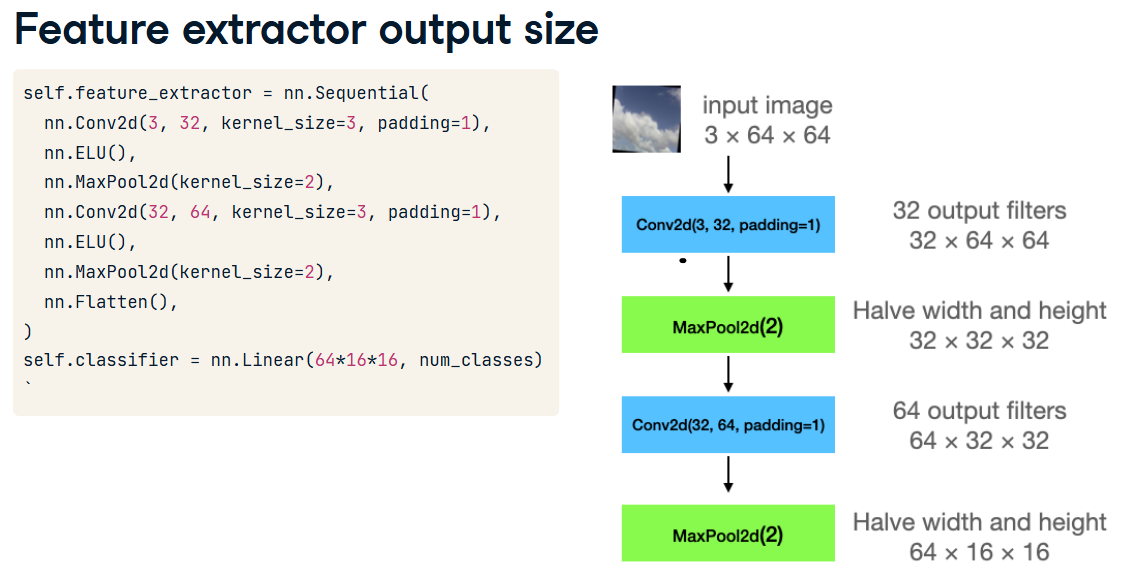


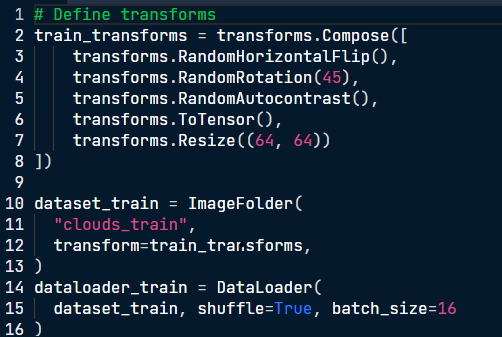

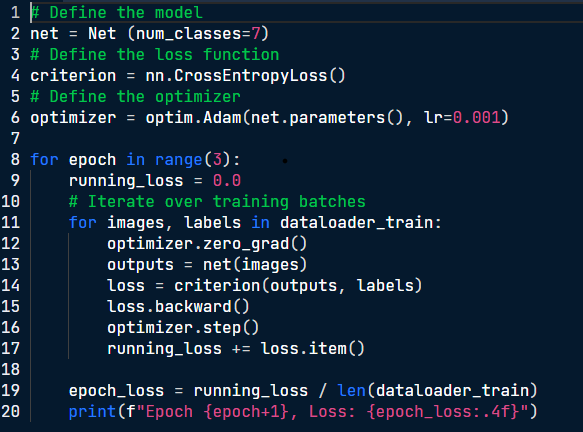

## Evaluating image classifiers
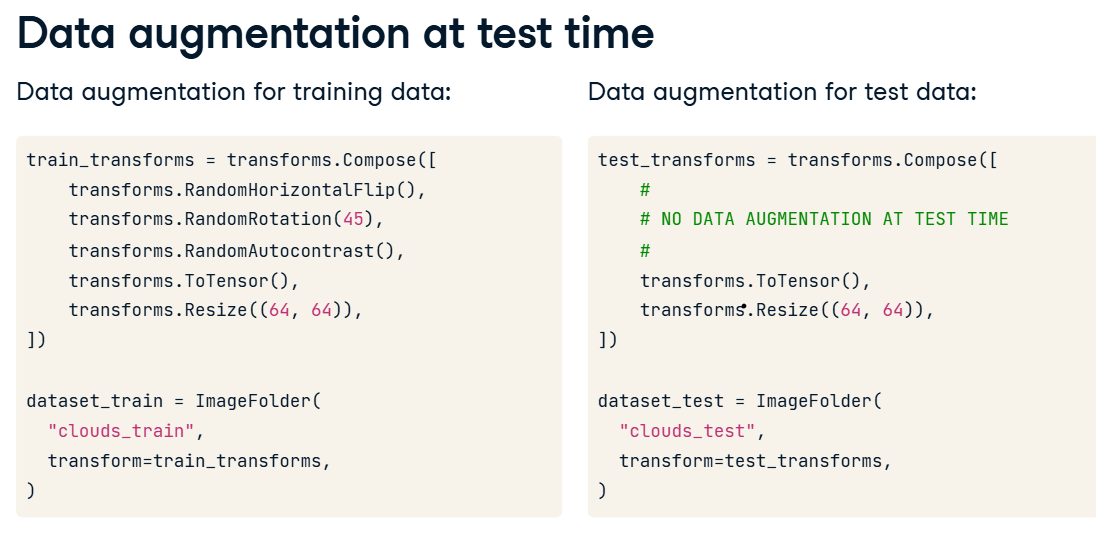

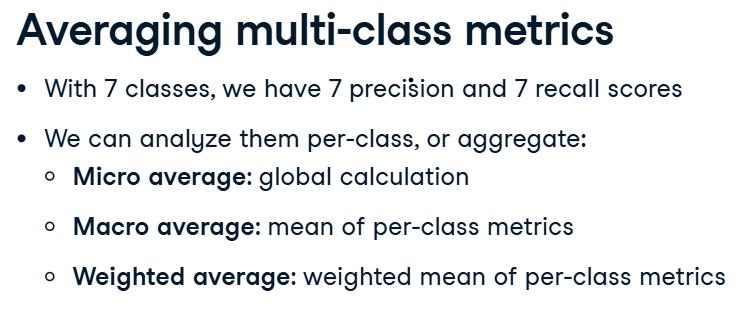

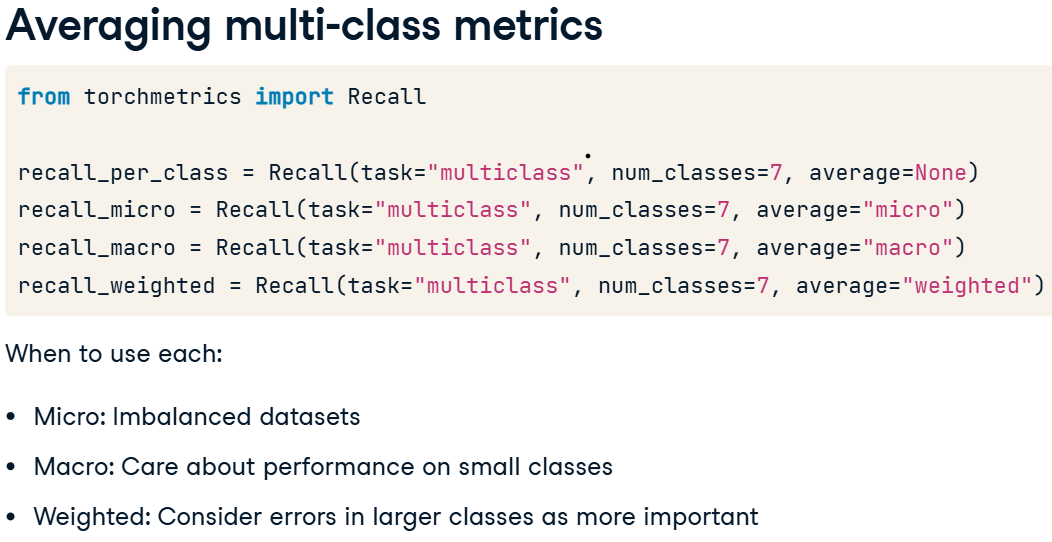

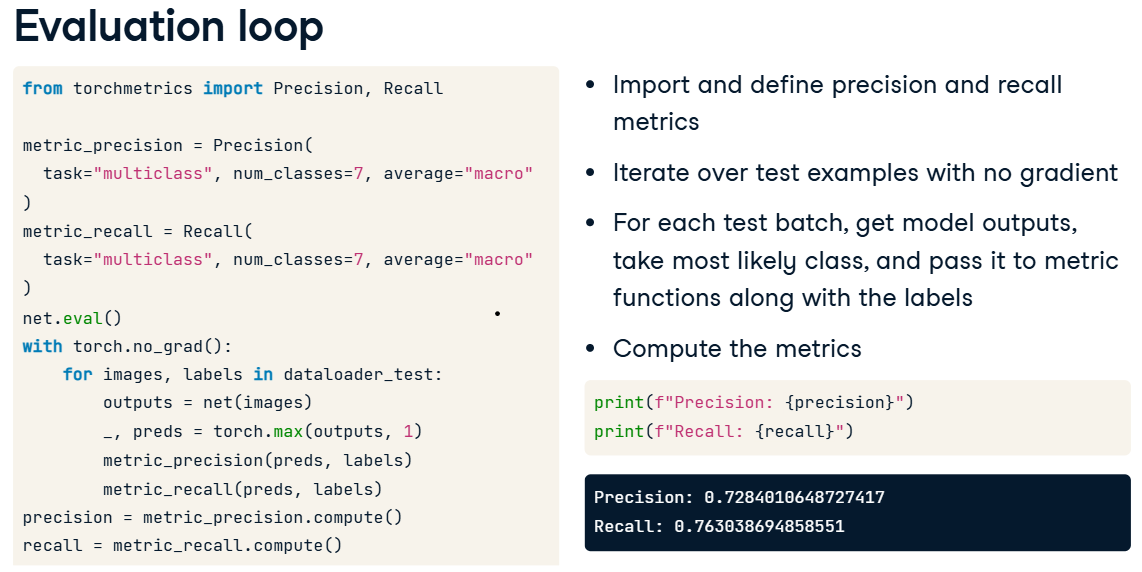

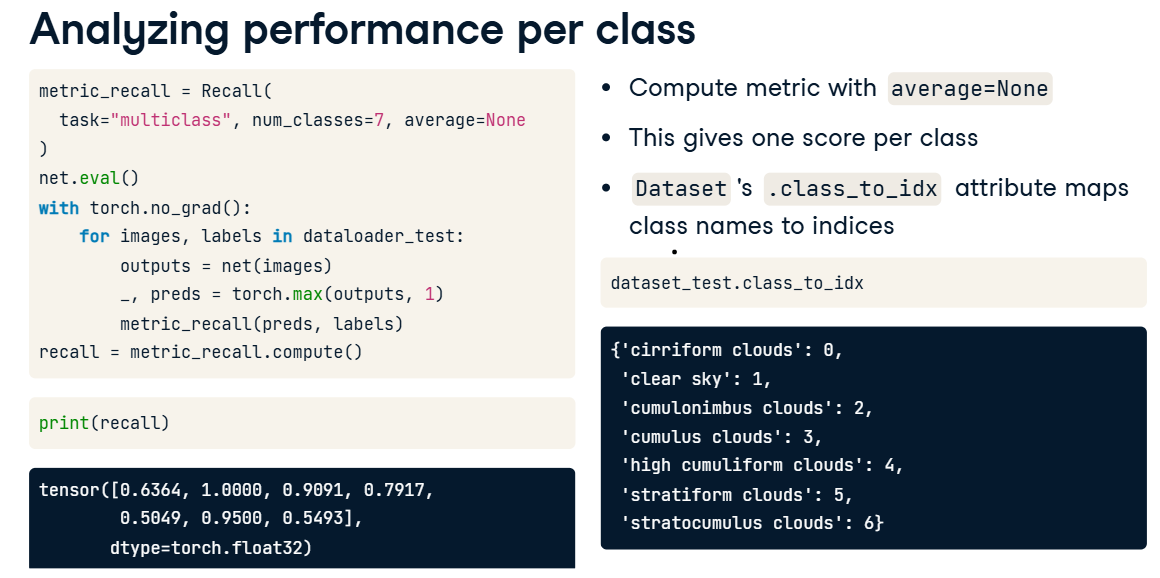

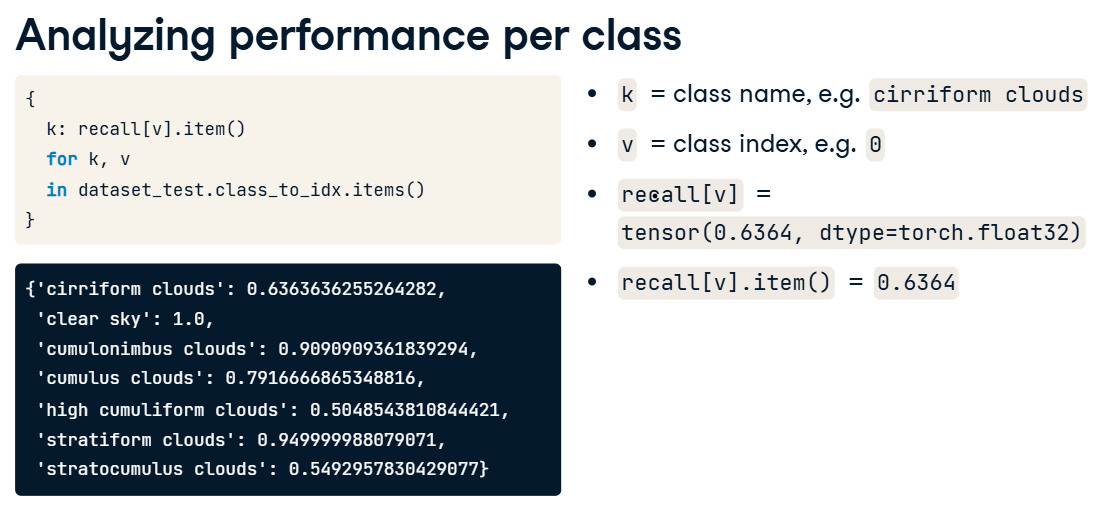

# Part 3: Sequences and Recurrent Neural Network
### Sequential data
Sequential data is ordered in time or space, where the order of the data points is important and can contain temporal or spatial dependencies between them. Time series, data recorded over time like stock prices, weather, or daily sales is sequential. So is text, in which the order of words in a sentence determines its meaning. Another example is audio waves, where the order of data points is crucial to the sound reproduced when the audio file is played.

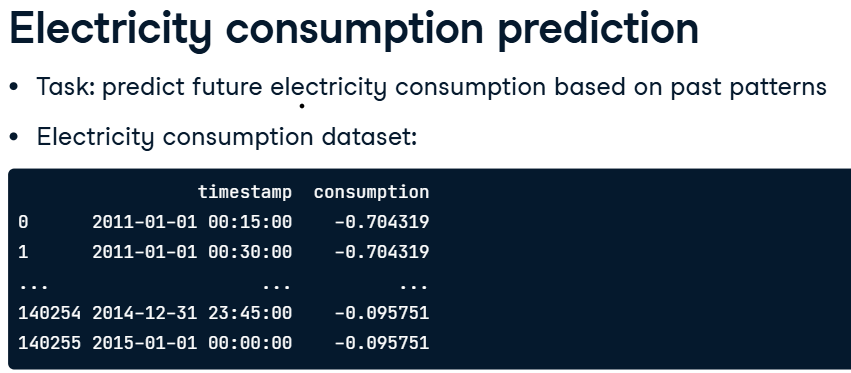

### Train-test split
In many machine learning applications, one randomly splits the data into training and testing sets. However, with sequential data, there are better approaches. If we split the data randomly, we risk creating a look-ahead bias, where the model has information about the future when making forecasts. In practice, we won't have information about the future when making predictions, so our test set should reflect this reality. To avoid the look-ahead bias, we should split the data by time. We will train on the first three years of data, and test on the fourth year.

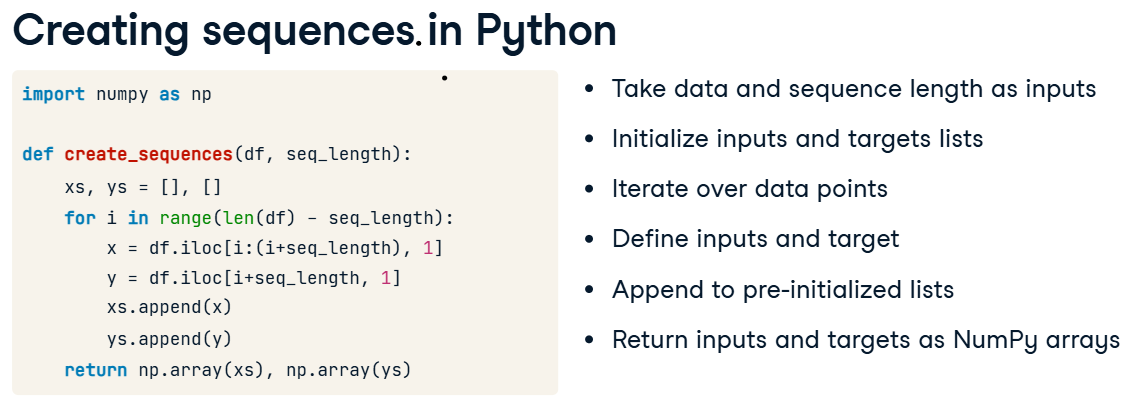

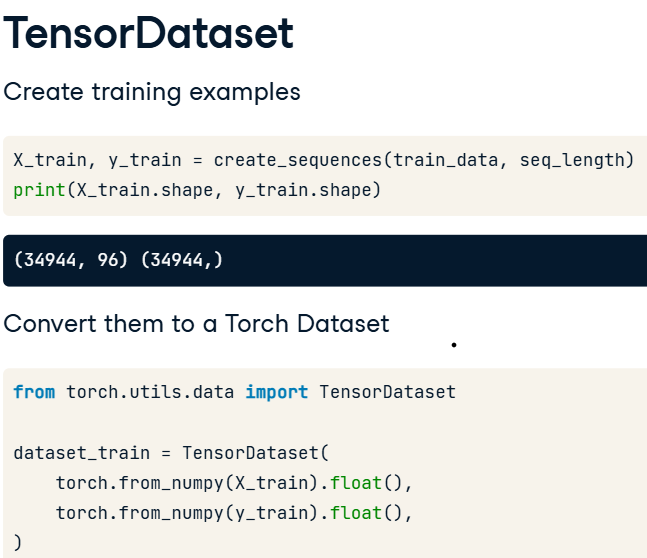



## RNN
Recurrent Neural Networks (RNNs) are a type of neural network designed for processing sequential data. Unlike traditional feedforward networks, RNNs have loops that allow information to persist, making them especially powerful for tasks where context or order matters (like time series, text, or speech).

### 🧠 What is the RNN doing?
At each step in a sequence (like a word in a sentence), the RNN:

Takes the current input (e.g. the current word),

Combines it with what it remembers from the previous step,

Produces a new memory (called the hidden state),

Optionally, makes a prediction or output.

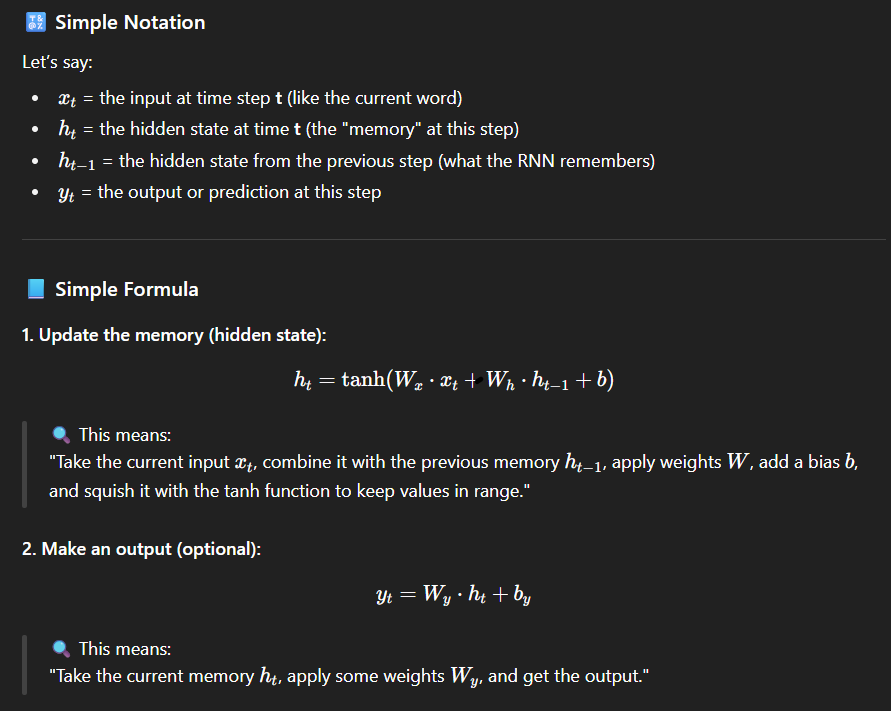

### ❌ Limitations of Basic RNNs
Vanishing/Exploding gradients: During training, gradients can become too small or too large, making learning difficult, especially over long sequences.

Short-term memory: Standard RNNs struggle with learning long-term dependencies.

We can also stack multiple layers of recurrent cells on top of each other to get a deep recurrent neural network. In this case, each input will pass through multiple neurons one after another, just like in dense and convolutional networks we have discussed before.

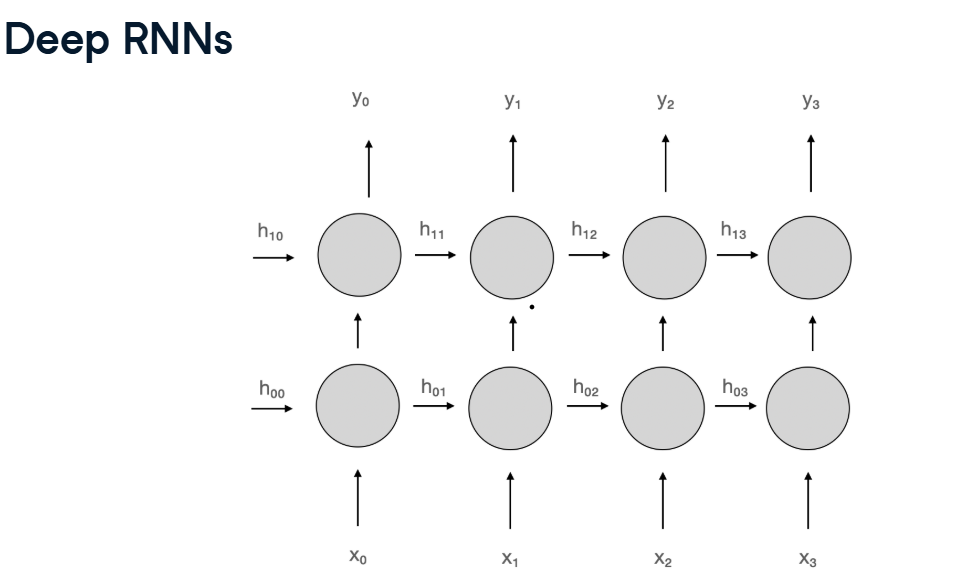

### Depending on the lengths of input and output sequences, we distinguish four different architecture types.

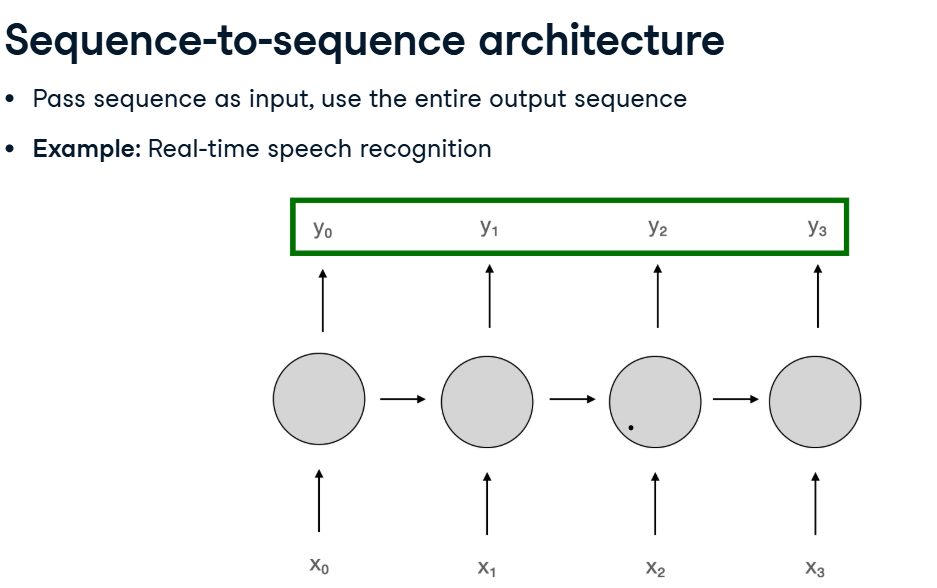

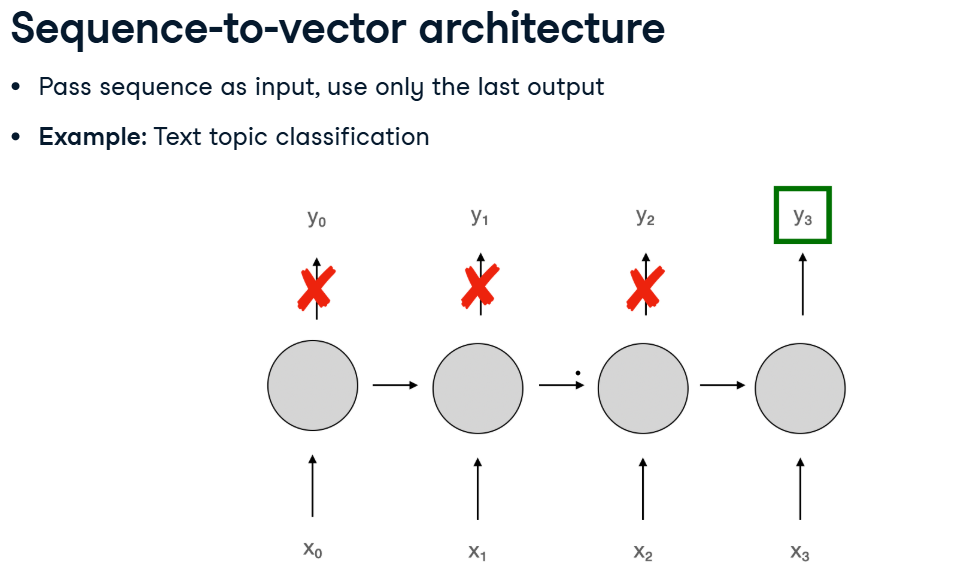

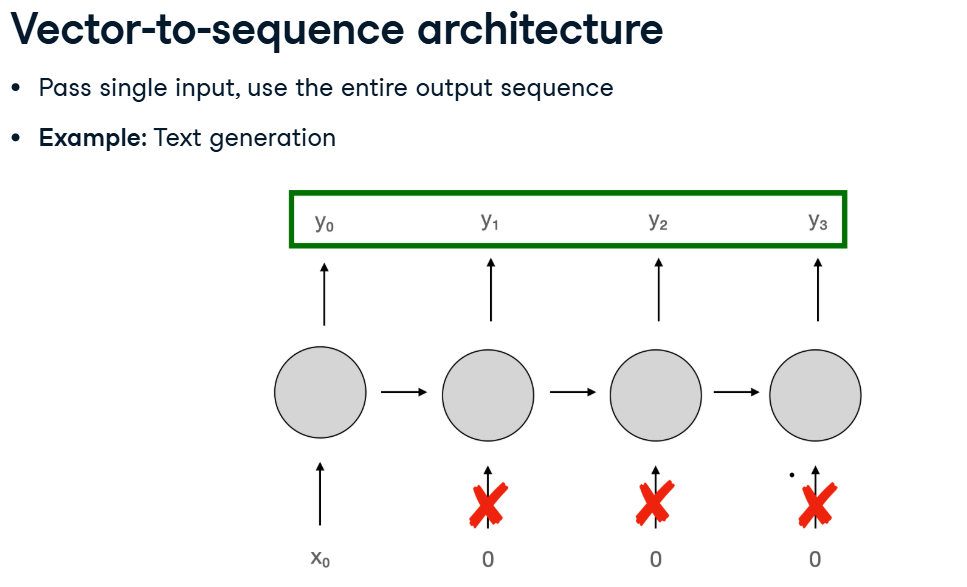

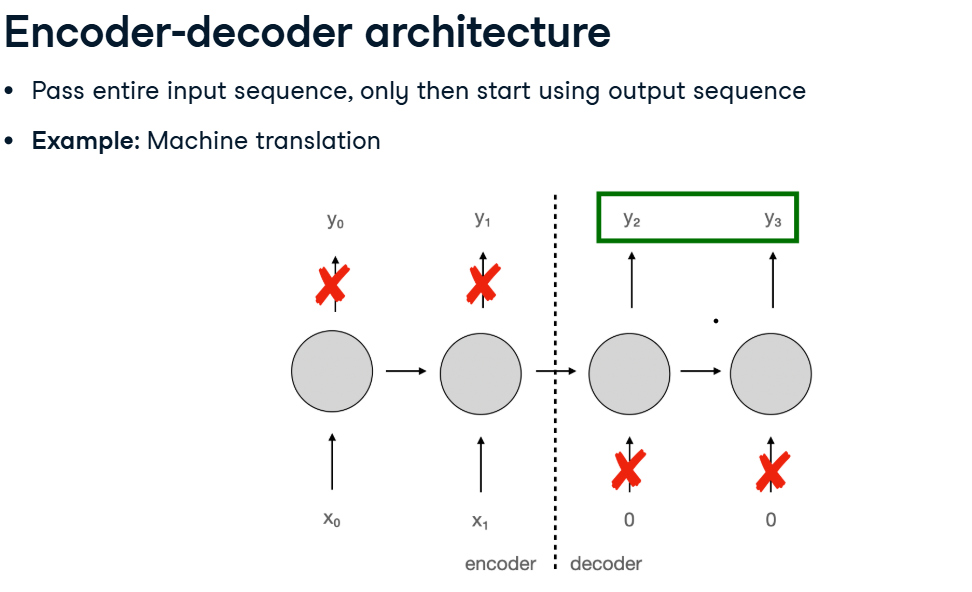

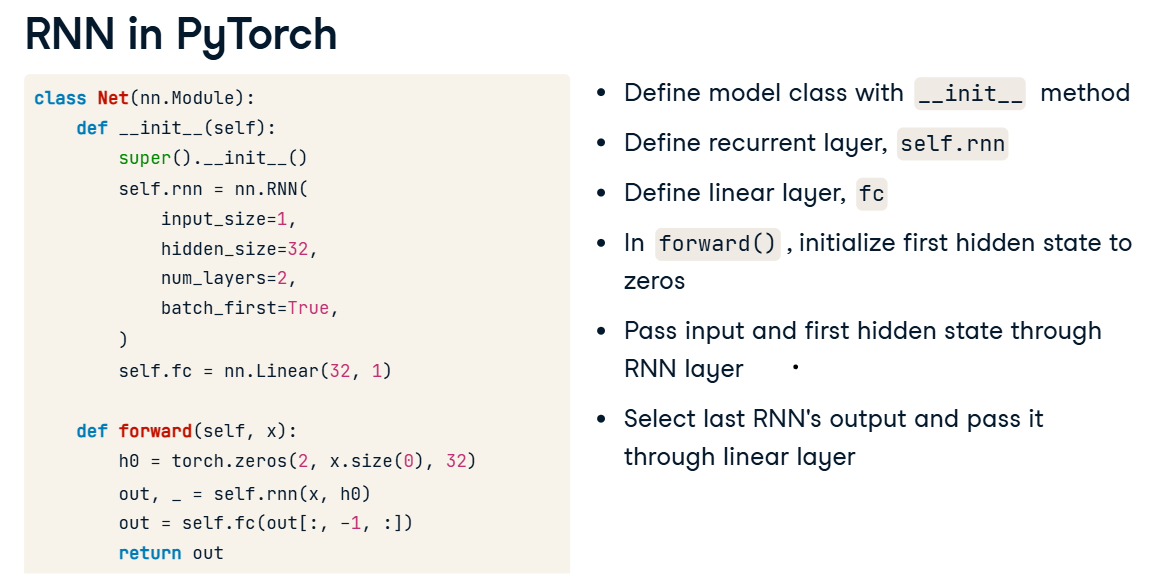

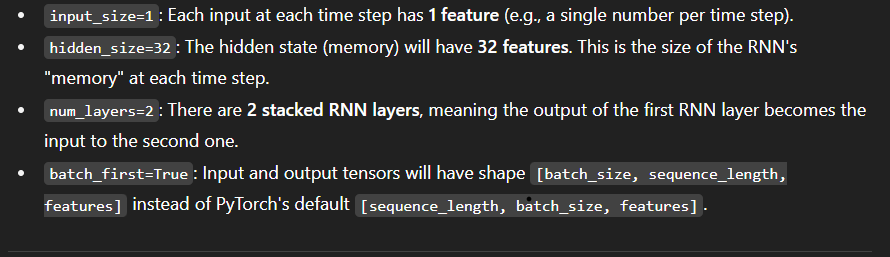

out: Contains outputs from the last RNN layer at each time step → shape: [batch_size, sequence_length, hidden_size]  
out[:, -1, :]: Picks the RNN output from the last time step.

: → for all batches

-1 → last time step

: → all 32 features

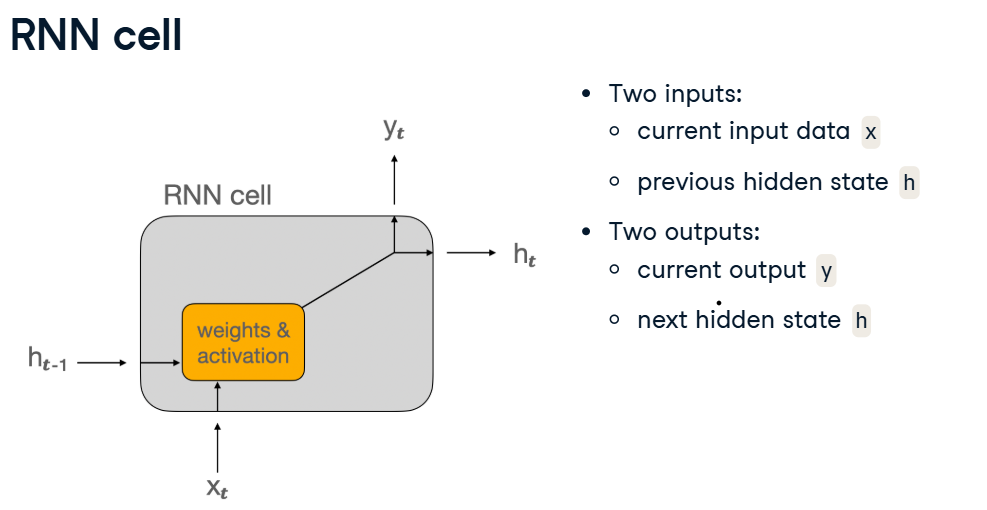

### 🔁 Why LSTM and GRU?
Basic RNNs struggle with:

Vanishing gradients (can’t learn long-term dependencies),

Forgetting earlier parts of sequences over time.

LSTM and GRU solve this by using gates to control what information is remembered or forgotten over time.

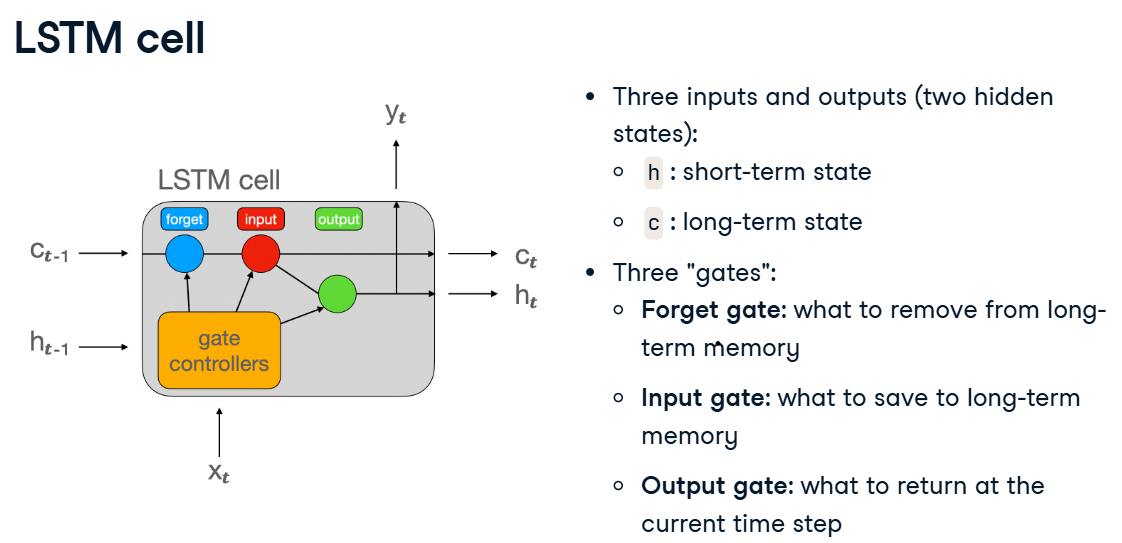

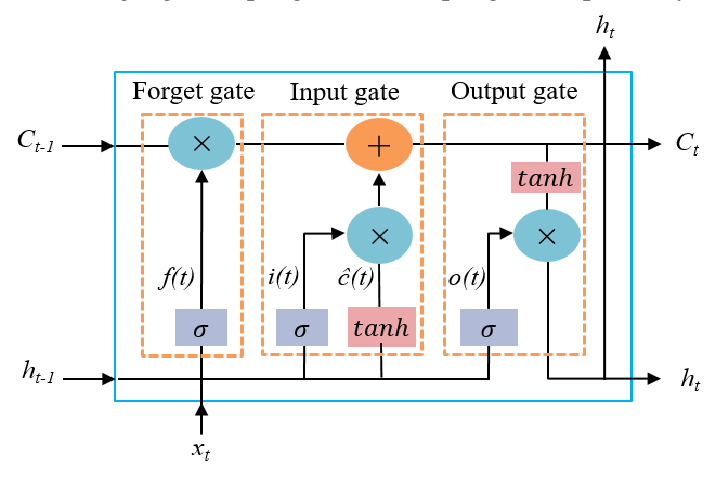

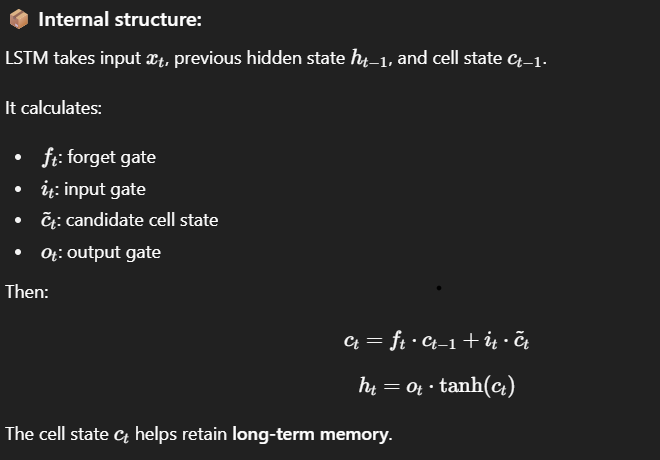

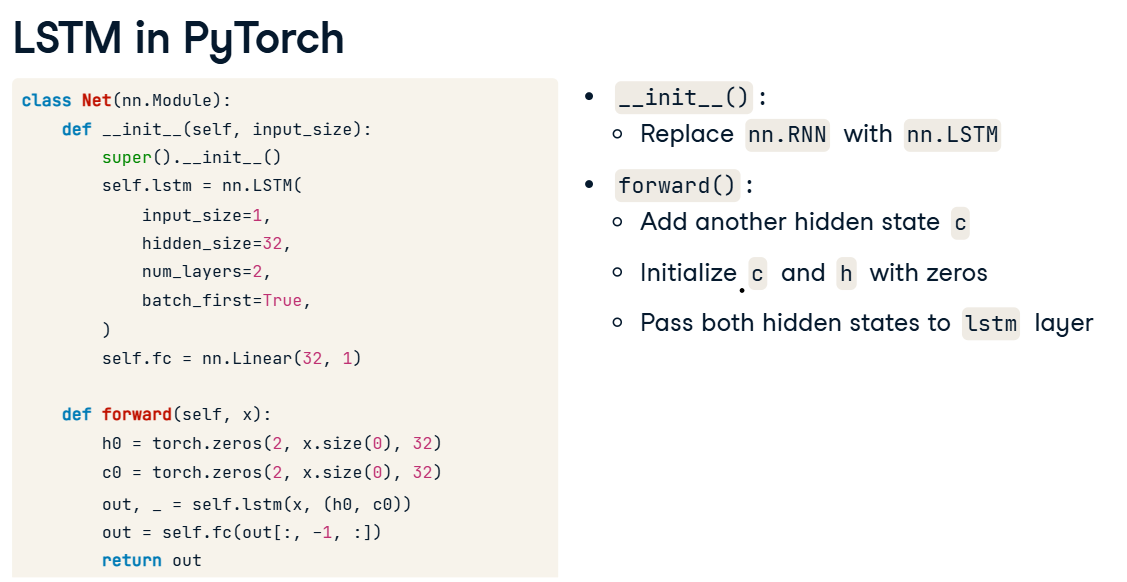

### ⚙️ GRU – Gated Recurrent Unit
✅ What’s special?
GRU is a simplified version of LSTM with only 2 gates:

Update gate – How much to keep from the past

Reset gate – How much of the past to forget

It doesn’t have a separate cell state—just the hidden state.

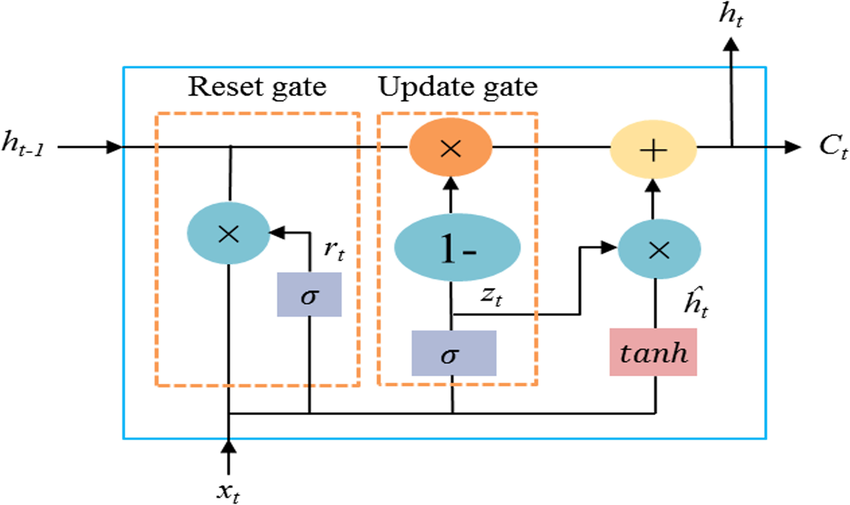

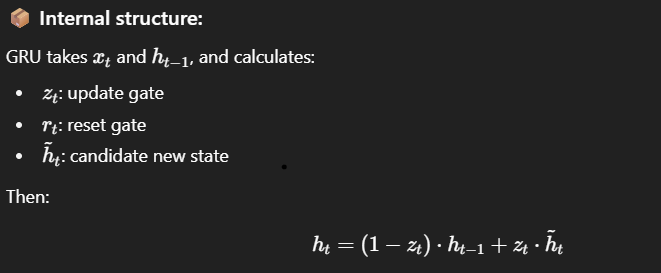

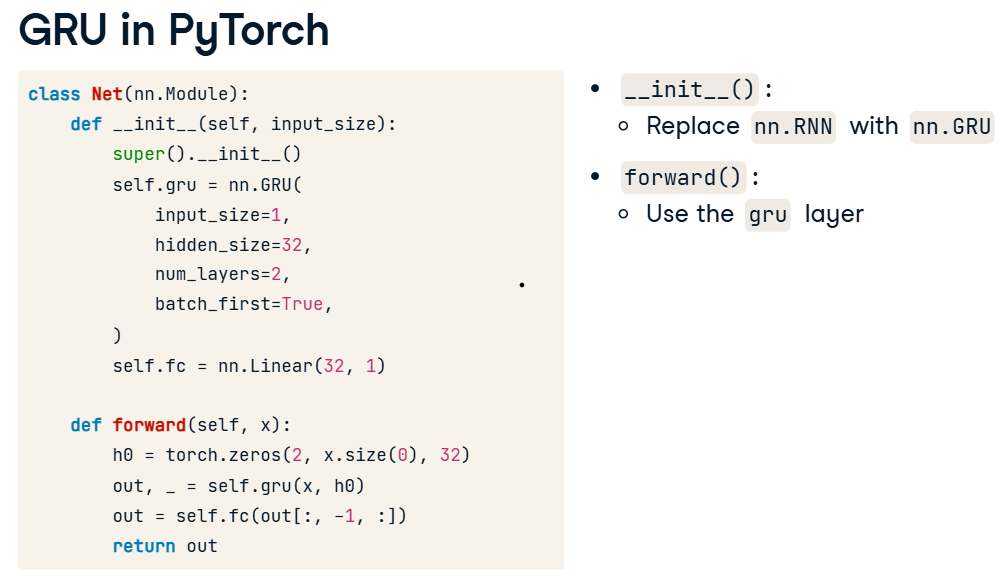
